<a href="https://colab.research.google.com/github/07hinata/RNN/blob/main/cisteni_dat_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

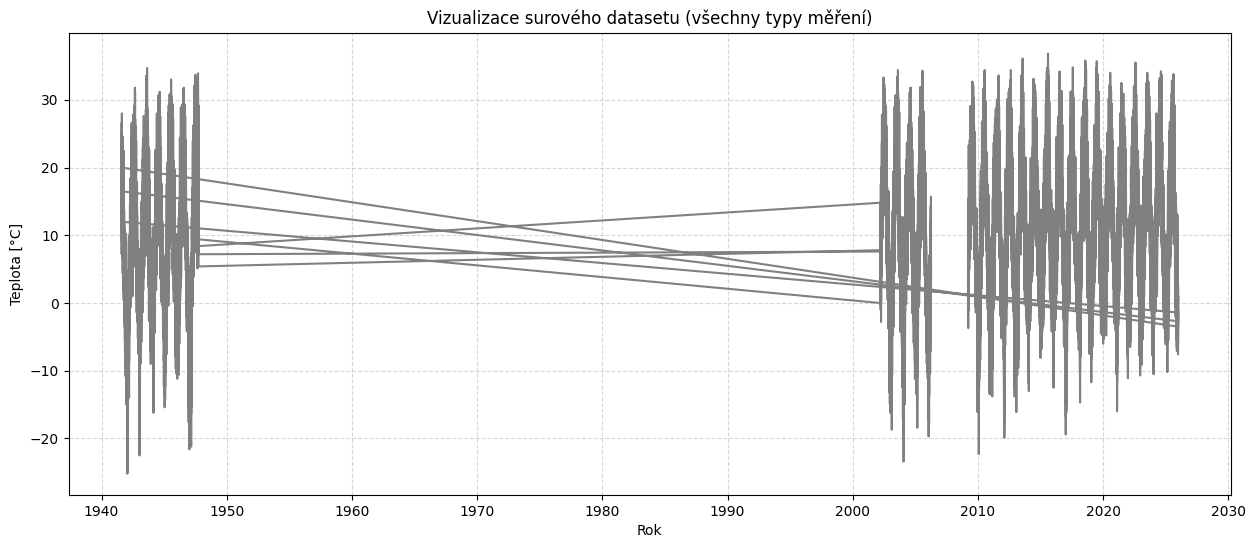

In [ ]:
# 1 vizualizace surového datového setu v grafu

import pandas as pd
import matplotlib.pyplot as plt

cols = ['ID', 'STANICE', 'TYP', 'DT', 'VALUE', 'X', 'Y', 'Z']
df_raw = pd.read_csv('dly-0-203-0-11651-T.csv', names=cols, skiprows=1)
df_raw['DT'] = pd.to_datetime(df_raw['DT'])

plt.figure(figsize=(15, 6))
plt.plot(df_raw['DT'], df_raw['VALUE'], color='grey')

plt.title('Vizualizace surového datasetu (všechny typy měření)')
plt.ylabel('Teplota [°C]')
plt.xlabel('Rok')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

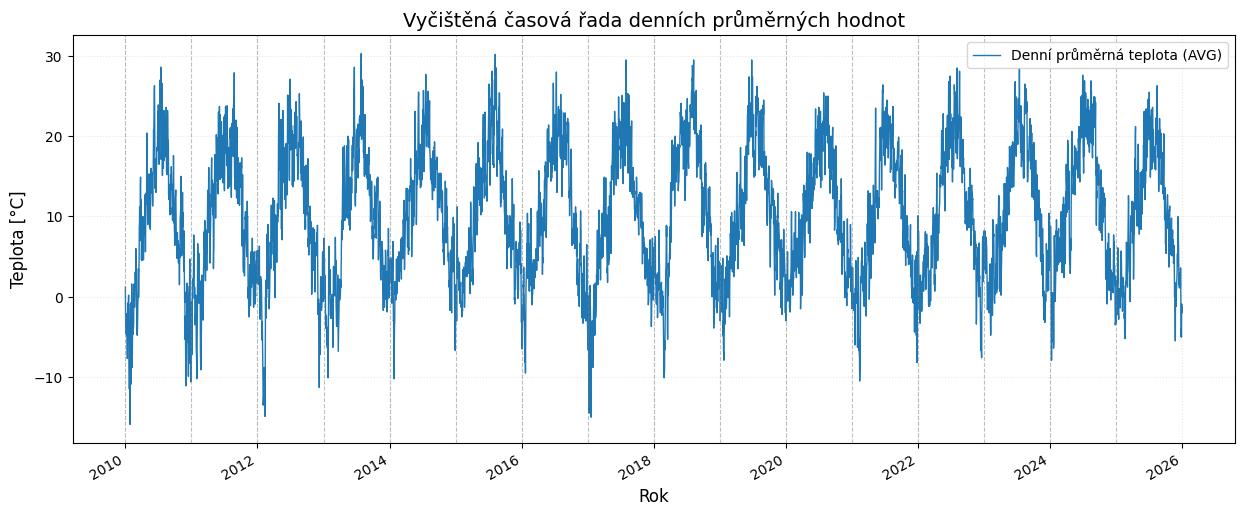

In [ ]:
# 2 vizualizace finálního datového setu v grafu - jen AVG, od 1. ledna 2010 do 31. prosince 2025

start_date = '2010-01-01'
end_date = '2025-12-31'

df_avg = df_raw[df_raw['TYP'] == 'AVG'].copy()
df_filtered = df_avg[(df_avg['DT'] >= start_date) & (df_avg['DT'] <= end_date)].copy()

plt.figure(figsize=(15, 6))
plt.plot(df_filtered['DT'], df_filtered['VALUE'], linewidth=1, label='Denní průměrná teplota (AVG)', zorder=2)

roky = df_filtered['DT'].dt.year.unique()
for rok in roky:
  plt.axvline(pd.Timestamp(f'{rok}-01-01'), color='gray', linestyle='--', linewidth=0.8, alpha=0.5)

plt.title('Vyčištěná časová řada denních průměrných hodnot', fontsize=14)
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Teplota [°C]', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.3)
plt.gcf().autofmt_xdate()

plt.legend()
plt.show()

In [ ]:
# 3 kontrola chybějících dní

pocet_dni = f"Počet chybějících dní: {df_filtered['VALUE'].isna().sum()}"

print(pocet_dni)

Počet chybějících dní: 0


In [ ]:
# 4 kontrola extrémních hodnot (pod -40 °C a nad 40 °C)

extremy = df_raw[ (df_raw['VALUE'] < -40) | (df_filtered['VALUE'] > 40) ]

print(extremy)

Empty DataFrame
Columns: [ID, STANICE, TYP, DT, VALUE, X, Y, Z]
Index: []


In [ ]:
# 5 kontrola konstantních hodnot

df_filtered['blok'] = df_filtered['VALUE'].diff().ne(0).cumsum()
delka_bloku = df_filtered.groupby('blok')['VALUE'].transform('size')
blok_dat = df_filtered[delka_bloku > 3]

print(blok_dat[['DT', 'VALUE']])

                            DT  VALUE
6872 2017-10-15 00:00:00+00:00   13.0
6873 2017-10-16 00:00:00+00:00   13.0
6874 2017-10-17 00:00:00+00:00   13.0
6875 2017-10-18 00:00:00+00:00   13.0


In [ ]:
# 6 kontrola extrémních rozdílů mezi dny

df_filtered['rozdil'] = df_filtered['VALUE'].diff().abs()

nej_rozdily = df_filtered.sort_values(by='rozdil', ascending=False).head(10)

print("10 největších teplotních rozdílů mezi dvěma dny:")
print(nej_rozdily[['DT', 'VALUE', 'rozdil']])

10 největších teplotních rozdílů mezi dvěma dny:
                            DT  VALUE  rozdil
4055 2010-01-28 00:00:00+00:00   -1.8    14.1
4890 2012-05-12 00:00:00+00:00   10.8    11.3
8628 2022-08-06 00:00:00+00:00   17.2    11.3
4631 2011-08-27 00:00:00+00:00   17.3    10.6
8404 2021-12-25 00:00:00+00:00   -4.3     9.9
4058 2010-01-31 00:00:00+00:00  -10.9     9.8
7872 2020-07-11 00:00:00+00:00   13.6     9.5
4672 2011-10-07 00:00:00+00:00    7.8     9.5
6828 2017-09-01 00:00:00+00:00   12.8     9.1
9614 2025-04-18 00:00:00+00:00   12.2     9.0


In [ ]:
# 7 extrémní rozdíly (průměr rozdílů, hranice anomálií, počet anomálií)

mean_diff = df_filtered['rozdil'].mean()

std_diff = df_filtered['rozdil'].std()

anomalie = df_filtered[df_filtered['rozdil'] > (mean_diff + 3 * std_diff)]

print(f"Průměrná mezi-denní změna byla: {mean_diff:.2f} °C")
print(f"Hranice pro anomálii byla: {mean_diff + 3 * std_diff:.2f} °C")
print(f"Počet statisticky neobvyklých rozdílů: {len(anomalie)}")

Průměrná mezi-denní změna byla: 1.93 °C
Hranice pro anomálii byla: 6.64 °C
Počet statisticky neobvyklých rozdílů: 85
